<h3>Epileptic Seizure Detection

Data source: https://archive.ics.uci.edu/dataset/1134/beed:+bangalore+eeg+epilepsy+dataset

In [1]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
RAW_DATA_PATH = RAW_DATA_DIR / "BEED_Data.csv"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
raw_data = pd.read_csv(RAW_DATA_PATH)
raw_data.head(20)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0
5,-47,-52,-45,-41,-29,-24,-21,-19,-13,-3,-2,4,11,14,11,14,0
6,-67,-30,7,33,51,79,105,122,132,115,83,42,10,-22,-47,-57,0
7,72,60,67,69,55,46,30,23,31,40,51,54,65,69,60,50,0
8,56,14,-12,-38,-73,-115,-137,-130,-78,-18,33,85,132,196,244,258,0
9,-17,-16,-12,13,53,84,77,57,24,-20,-39,-45,-40,-35,-19,-4,0


- X1 - X16 are the EEG instrument channels corresponding to different brain regions.
- y is a value indicating from 0 to 3:
    - 3 – Recording of seizure events (including activities such as eye blinking or constant staring)
    - 2 – Recording of focal seizures
    - 1 – Recording of generalized seizures
    - 0 – Recording of healthy subjects (control group without epileptic seizures)

- Each row is a single 20-second recording

In [4]:
raw_data['y'].nunique()
# Multiclass target

4

In [5]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      8000 non-null   int64
 1   X2      8000 non-null   int64
 2   X3      8000 non-null   int64
 3   X4      8000 non-null   int64
 4   X5      8000 non-null   int64
 5   X6      8000 non-null   int64
 6   X7      8000 non-null   int64
 7   X8      8000 non-null   int64
 8   X9      8000 non-null   int64
 9   X10     8000 non-null   int64
 10  X11     8000 non-null   int64
 11  X12     8000 non-null   int64
 12  X13     8000 non-null   int64
 13  X14     8000 non-null   int64
 14  X15     8000 non-null   int64
 15  X16     8000 non-null   int64
 16  y       8000 non-null   int64
dtypes: int64(17)
memory usage: 1.0 MB


So far it seems like a fairly simple dataset in terms of datatypes (all integers). There also appears to be no null or missing values:

In [6]:
raw_data.isna().any(axis=1).sum()
# Returns 0

np.int64(0)

No imputation will be required in this case. The hardest part of this will likely be the feature selection.

N.B. 
- The only conversion/encoding that will be needed here will be on the target ('y'). It looks like there is some ordering when comparing 3,2, and 1 (seizure events) to 0 (no seizure events), but no apparent ordering when comparing 3, 2 and 1 with eachother. Will consider a nominal encoding technique over an ordinal one.
- I could add a new feature which is binary, where 0 is no seizure and 1 is any type of seizure, computed from 'y' A downside to this may be the introduction of class imbalance which would required the introduction of sampling techniques into the pipeline. The target will however become ordinal.



<h4>EDA

*Distribution and Outlier Analysis*

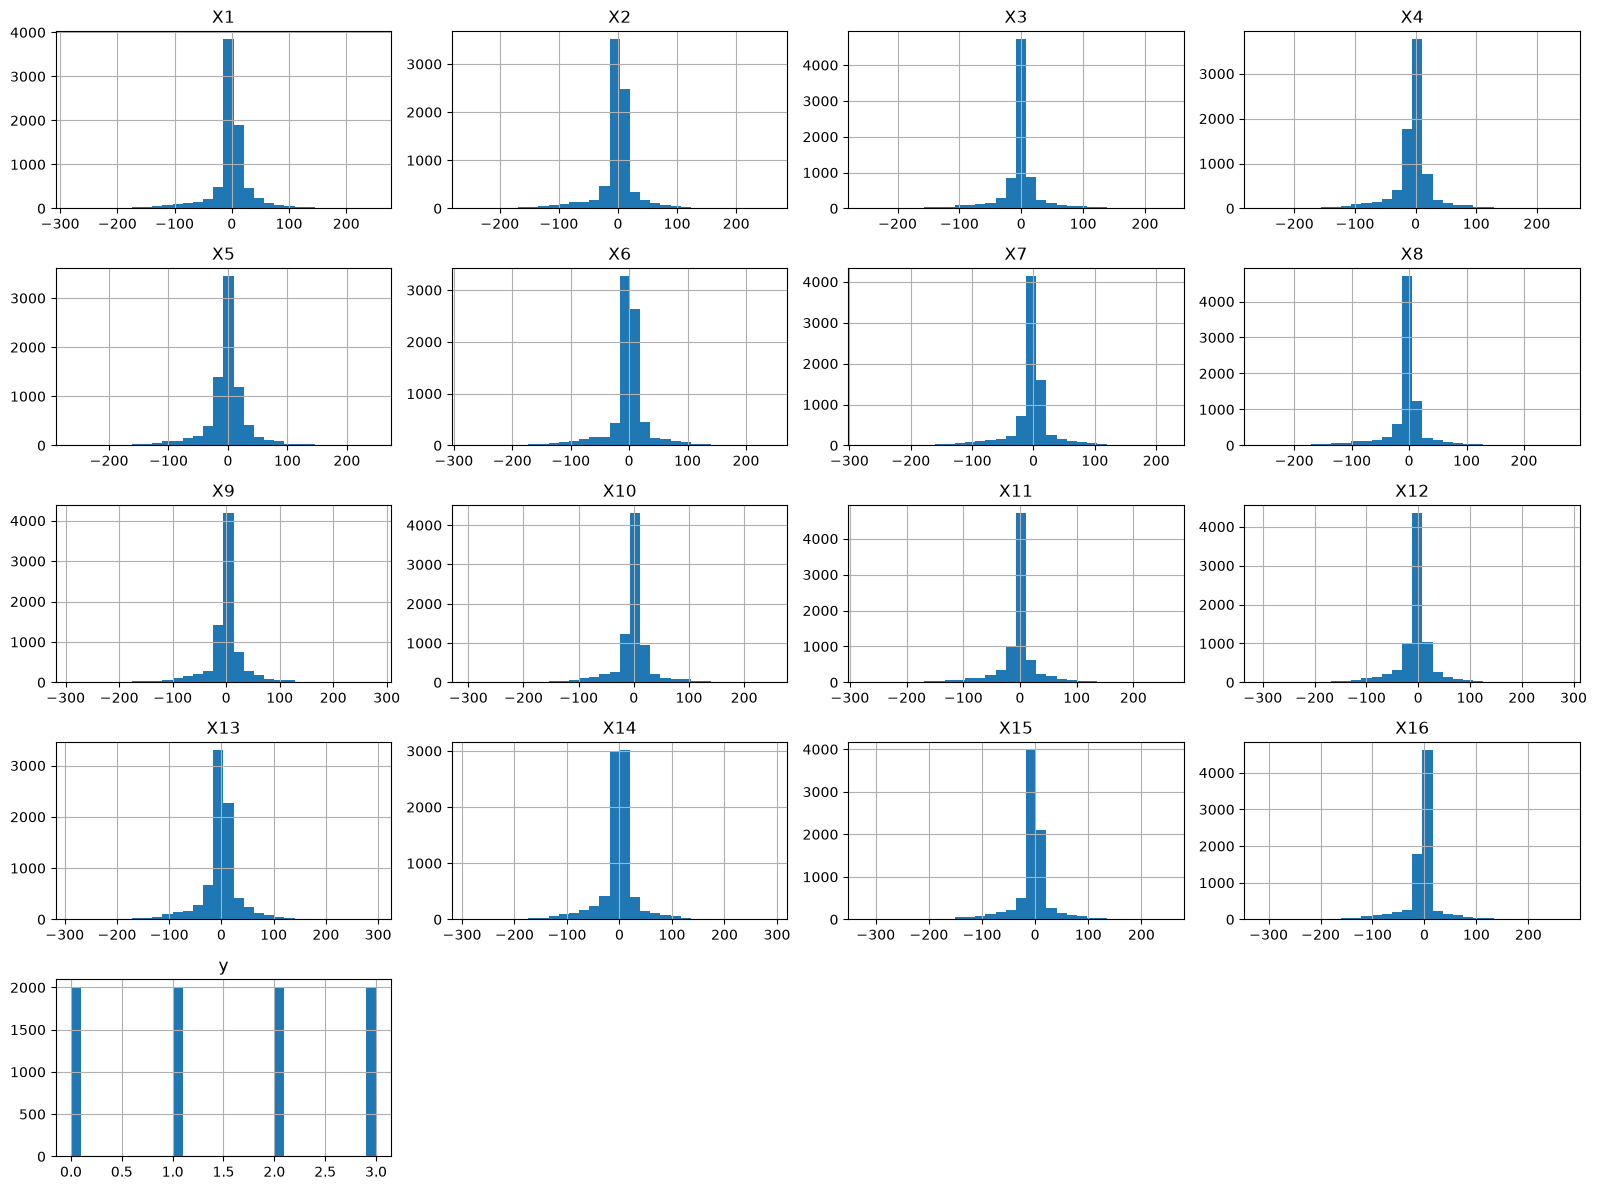

In [7]:
raw_data.hist(figsize=(16, 12), layout=(5, 4), bins=30)
plt.tight_layout()

Observations:
- Very balanced target class 'y'. Appears to be 25% for each of the 4 classes. If I were to make this a binary classification problem as described in the previous section by creating a new binary target of seizure presence (1), or no-seizure presence (0), class imbalance would be introduced (at a 3:1 ratio)
- The feature columns seem to have mean values of around 0. Hard to spot outliers here visually so will need to double check outlier presence using other techniques.

In [8]:
import seaborn as sns

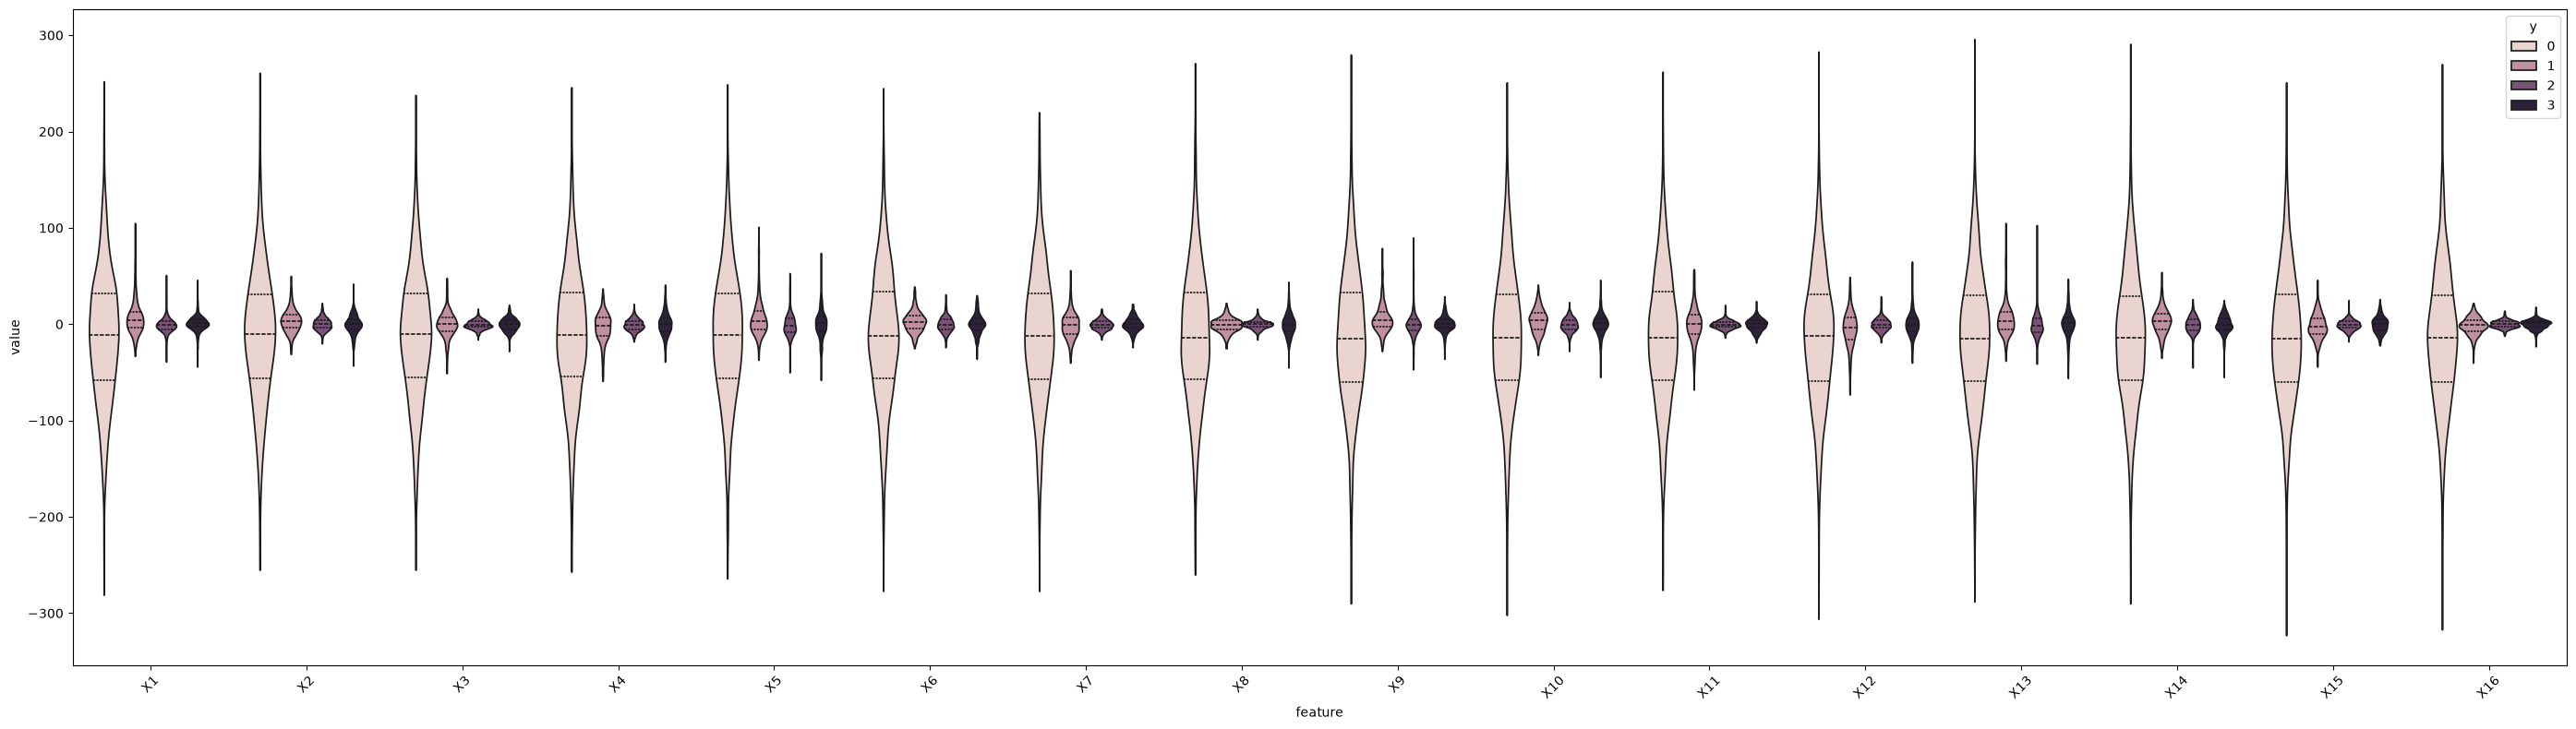

In [9]:
# Violin plots by class for each feature
plot_df = raw_data.melt(id_vars='y', var_name='feature', value_name='value')
plt.figure(figsize=(28, 8))
sns.violinplot(data=plot_df, x='feature', y='value', hue='y', cut=0, inner='quartile')
plt.xticks(rotation=45)
plt.tight_layout()

The violin plots appear to show a fairly evenly distrubuted set of values for each of the features as a function of the target class as shown by the 'even' shapes of the violins.

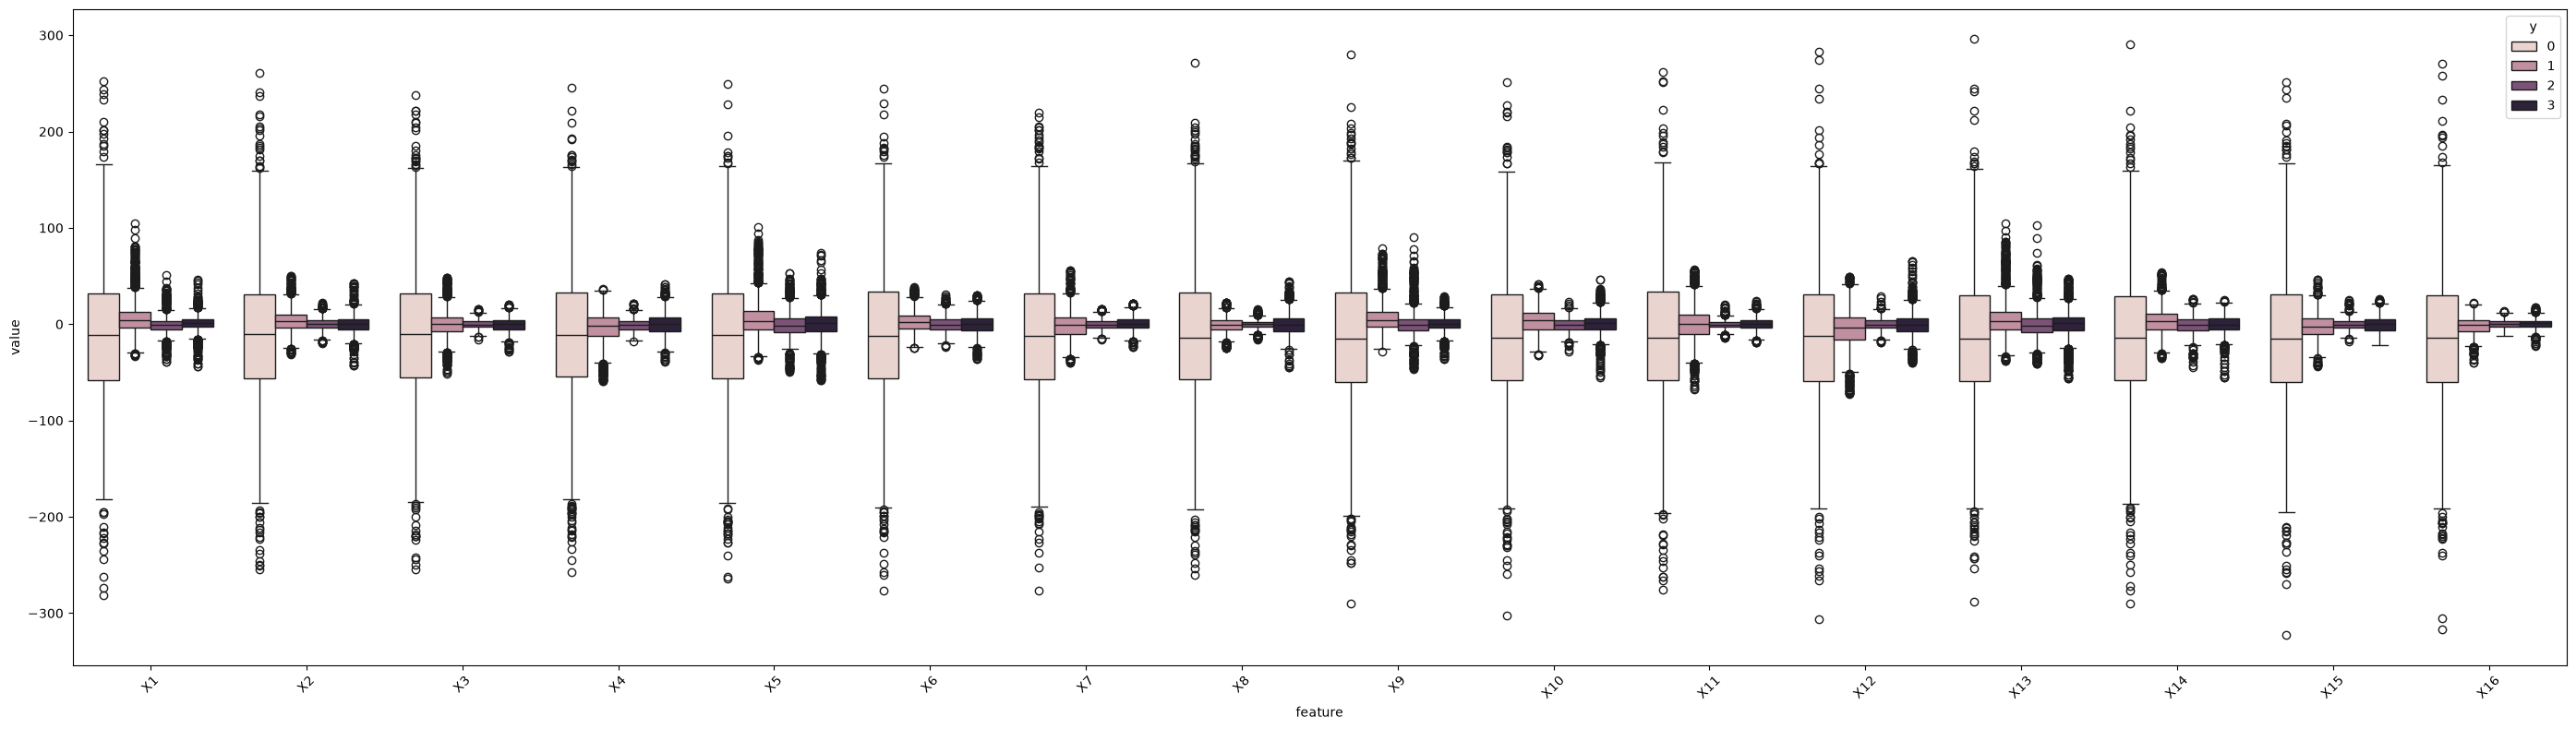

In [10]:
# Boxplots by class for each feature
plot_df = raw_data.melt(id_vars='y', var_name='feature', value_name='value')
plt.figure(figsize=(28, 8))
sns.boxplot(data=plot_df, x='feature', y='value', hue='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# By default, the 'threshold' of outlier detemination is 2.7x s.d. from the mean (Turkey's rule).

Based on the default 

Compute Z-scores to detect any outliers numerically (using threshold of Z = 3)

In [11]:
from scipy.stats import zscore

numeric_columns = raw_data.select_dtypes(include=np.number).columns.drop('y', errors='ignore')
X_numeric = raw_data[numeric_columns]

threshold = 3
z_scores = np.abs(zscore(X_numeric))
outliers_mask = (z_scores > threshold)

outlier_counts = pd.DataFrame({
    'feature': numeric_columns,
    'outlier_count': outliers_mask.sum(axis=0),
    'percentage': (outliers_mask.sum(axis=0) / len(X_numeric)) * 100
})

print(outlier_counts)

   feature  outlier_count  percentage
0       X1            229      2.8625
1       X2            233      2.9125
2       X3            239      2.9875
3       X4            227      2.8375
4       X5            211      2.6375
5       X6            236      2.9500
6       X7            234      2.9250
7       X8            245      3.0625
8       X9            223      2.7875
9      X10            227      2.8375
10     X11            225      2.8125
11     X12            218      2.7250
12     X13            197      2.4625
13     X14            218      2.7250
14     X15            223      2.7875
15     X16            238      2.9750


Not too many outliers present. Only ~3%. I'll remove them now based on the Z-scores (with a Z = 3 threshold):

In [12]:
# Keep only rows where no feature exceeds the Z-score threshold
non_outlier_mask = ~outliers_mask.any(axis=1)

data = raw_data.loc[non_outlier_mask].reset_index(drop=True)

print(f"Rows removed: {(~non_outlier_mask).sum()}")
print(f"Rows remaining: {len(data)}")

Rows removed: 873
Rows remaining: 7127


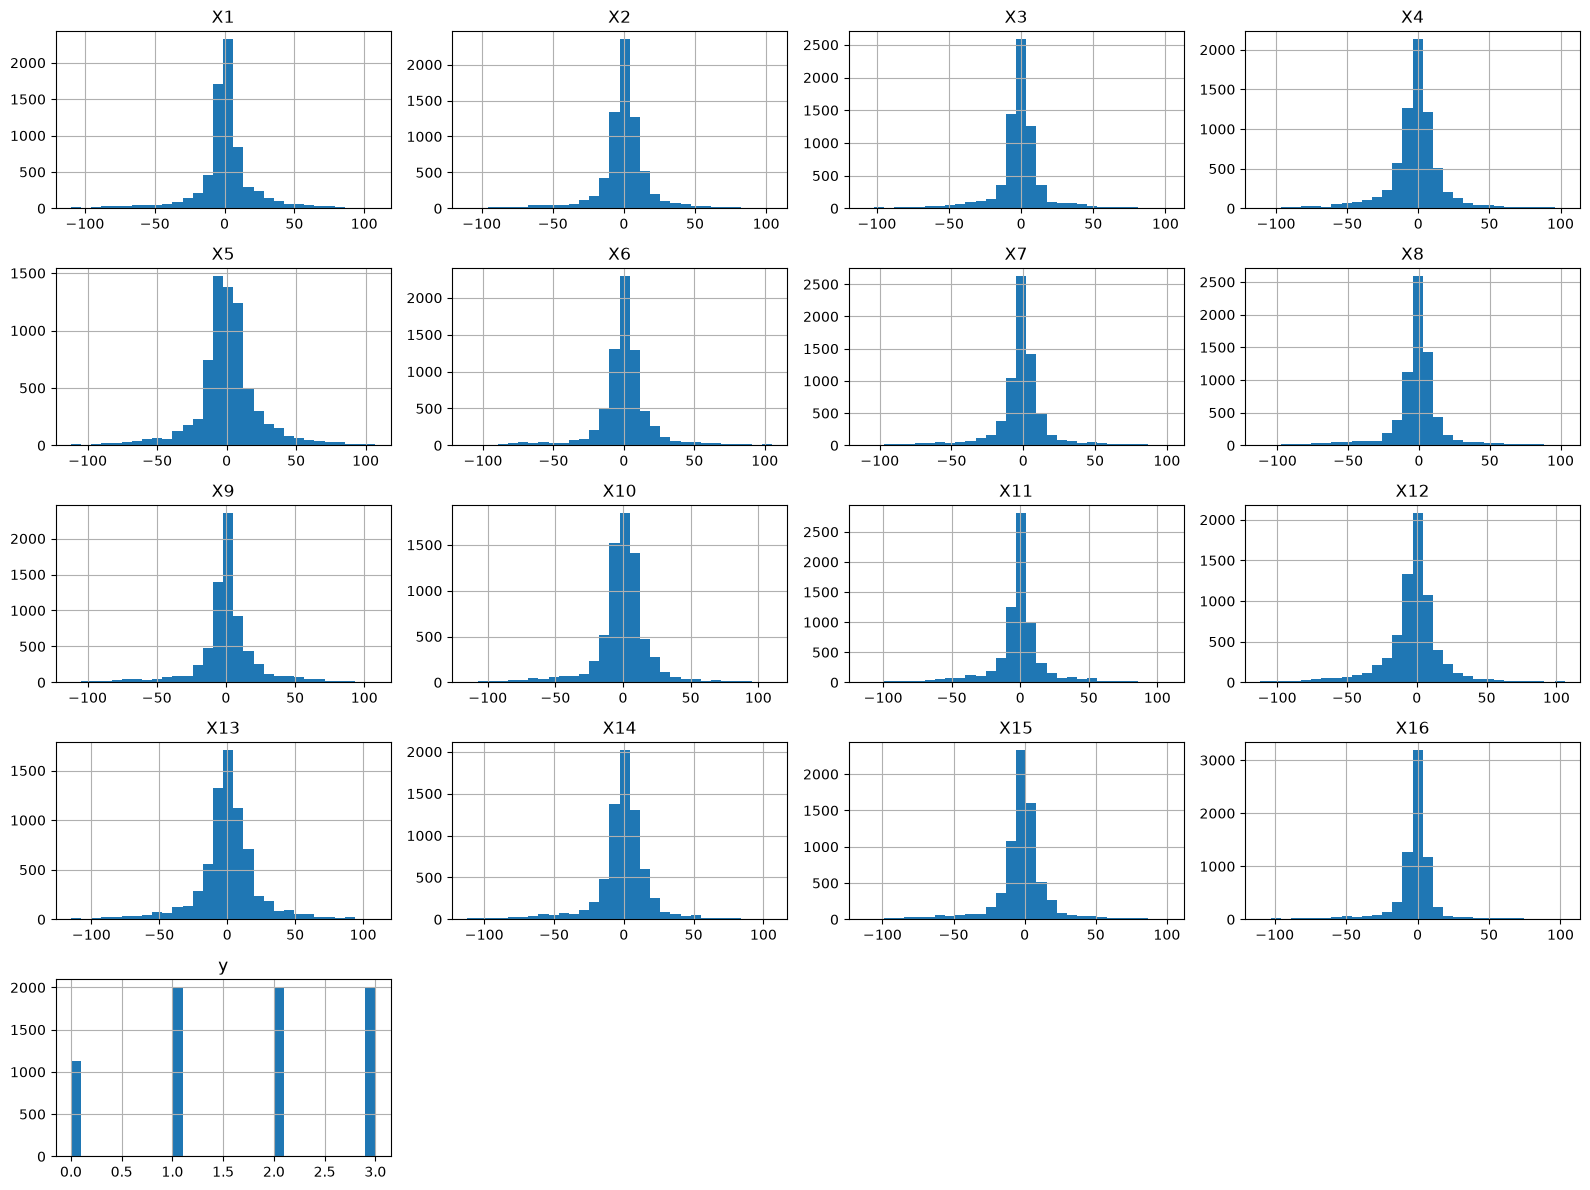

In [13]:
data.hist(figsize=(16, 12), layout=(5, 4), bins=30)
plt.tight_layout()

- Looking at the distribution of values in y some class imbalance has been introduced where lots of rows corresponding to 'y' = 0 have been removed. Interesting how such a large number of the outliers correspond to this target class specifically.
- We may need to do some sampling.

*Relationship and Correlation Analysis + Exploratory Feature Selection*

Correlation between features

In [14]:
features = data.drop(['y'],axis=1)
features.head(10)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10
1,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29
2,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41
3,-47,-52,-45,-41,-29,-24,-21,-19,-13,-3,-2,4,11,14,11,14
4,72,60,67,69,55,46,30,23,31,40,51,54,65,69,60,50
5,-17,-16,-12,13,53,84,77,57,24,-20,-39,-45,-40,-35,-19,-4
6,-38,-28,-23,-25,-23,-25,-32,-36,-35,-42,-54,-58,-62,-69,-82,-99
7,13,-7,-23,-25,-10,3,20,25,16,2,2,16,26,22,19,28
8,22,7,-26,-41,-29,3,-21,-37,-29,-37,-6,14,-37,-64,-82,-90
9,99,85,47,16,-19,-37,-67,-90,-108,-103,-69,-32,0,25,39,37


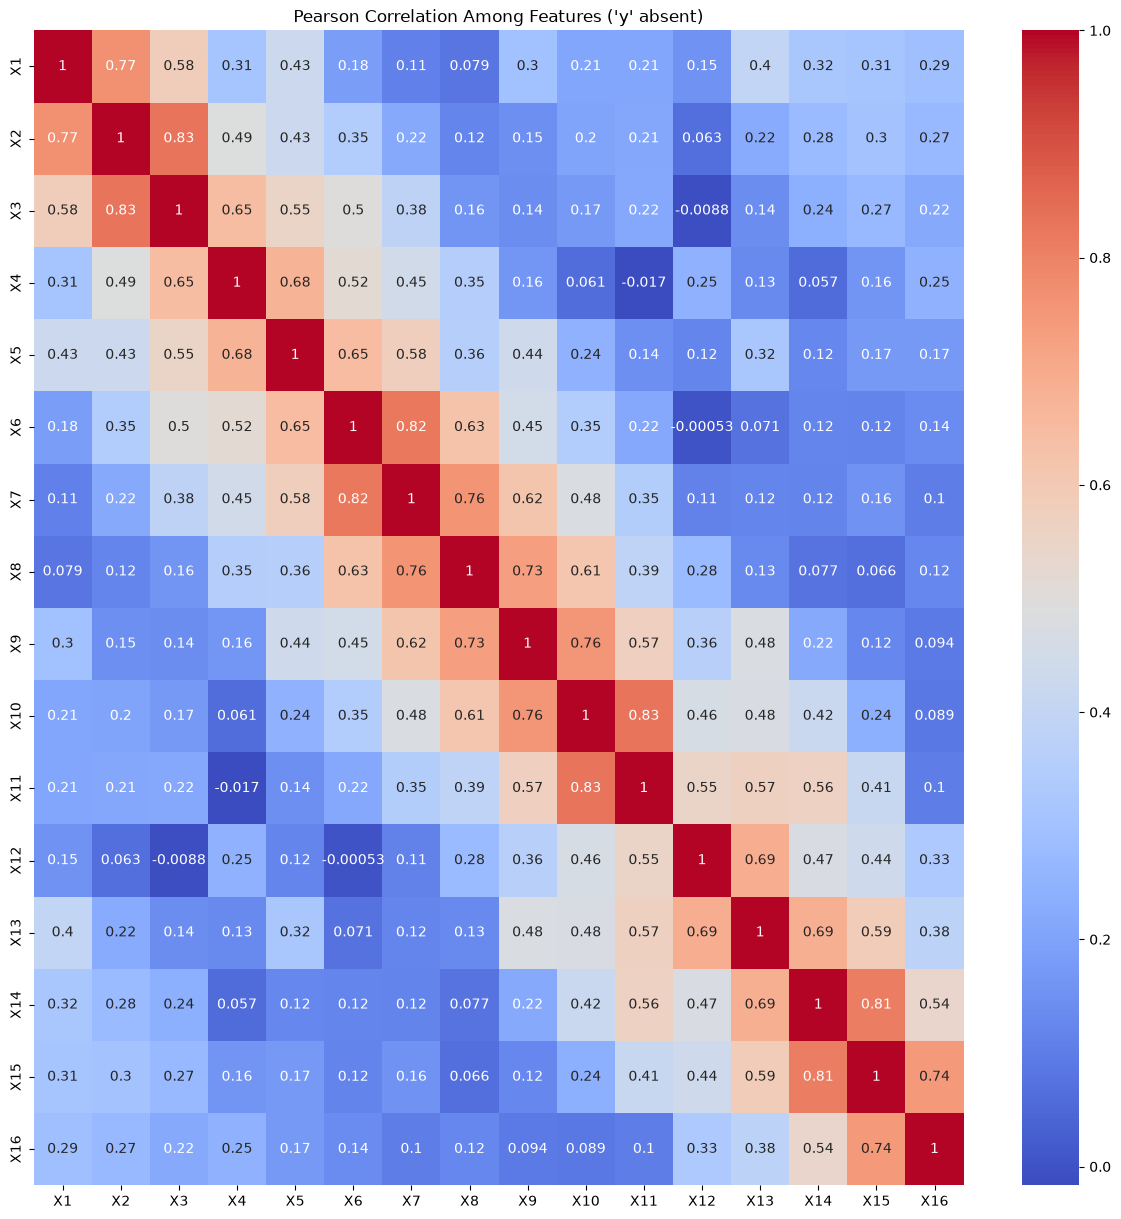

In [15]:
# Pearson Correlation (among features):
features_corr = features.corr(numeric_only=True)
plt.figure(figsize=(15, 15))
sns.heatmap(features_corr, 
            annot=True, 
            cmap='coolwarm'
            )
plt.title("Pearson Correlation Among Features ('y' absent)")
plt.show()

Regarding transformation of the nominal target variable: scikit-learn expects 1d data-structure for a target, so OneHot encoding may not be needed except if Keras models (i.e. neural nets) are to be explored. Keep as integers (0-3) for now

In [16]:
# VIF to spot multicollinearity:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler


VIF_features = data.select_dtypes(include=['int64', 'float64']).drop(columns=['y'], errors='ignore')

# Scaling for stability (not essential)
VIF_features_scaled = StandardScaler().fit_transform(VIF_features)

vif_df = pd.DataFrame()
vif_df['feature'] = VIF_features.columns
vif_df['VIF'] = [variance_inflation_factor(VIF_features_scaled, i) for i in range(VIF_features_scaled.shape[1])]

print(vif_df)

# Generally anything over 10 is a problem. 5-10 is moderate but overall not an issue.

   feature       VIF
0       X1  3.732971
1       X2  6.131112
2       X3  6.597222
3       X4  5.045686
4       X5  4.044643
5       X6  4.612688
6       X7  5.872711
7       X8  5.338045
8       X9  6.160225
9      X10  6.354697
10     X11  6.497451
11     X12  4.055581
12     X13  5.200266
13     X14  4.846544
14     X15  6.186795
15     X16  3.145198


Overall fairly non-colinear. Everything is less than 10.

Let's analyse any correlation that may be present between the features and target. Re-doing pearson correlation to include the target:

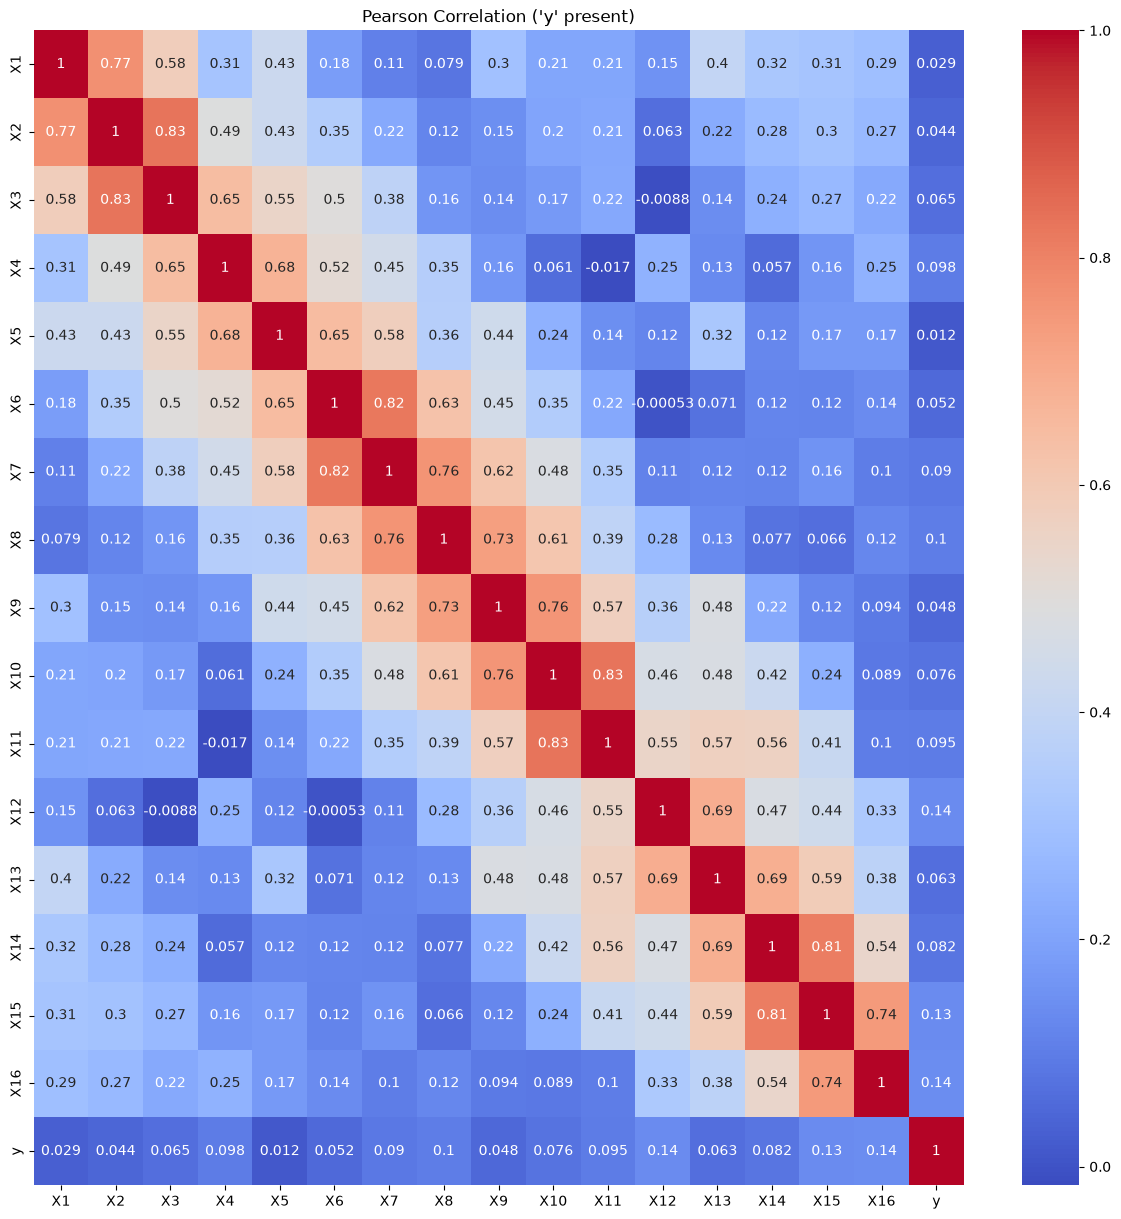

In [17]:
total_corr = data.corr(numeric_only=True)
plt.figure(figsize=(15, 15))
sns.heatmap(total_corr, 
            annot=True, 
            cmap='coolwarm'
            )
plt.title("Pearson Correlation ('y' present)")
plt.show()

Low correlation may be due to the nominal nature of the target. Pearson assumes ordinal nature in the target. Let's experiment with correlation ratio, ANOVA-F score, and mutual information (MI):

*Correlation ratio*

- The correlation ratio measures how much of the variation in a numeric feature is explained by class membership. 
- It is a value between 0 and 1. 
- Unlike Pearson correlation it doesn't assume ordering in the target.

In [18]:
def correlation_ratio(categories, values):
    categories = pd.Series(categories)
    values = pd.Series(values)

    valid = categories.notna() & values.notna()
    categories = categories[valid]
    values = values[valid]

    overall_mean = values.mean()

    ss_between = sum(
        len(group) * (group.mean() - overall_mean) ** 2
        for _, group in values.groupby(categories)
    )

    ss_total = ((values - overall_mean) ** 2).sum()

    return ss_between / ss_total if ss_total > 0 else 0.0

feature_columns = data.columns.drop('y')

eta_squared = pd.Series(
    {
        column: correlation_ratio(data["y"], data[column])
        for column in feature_columns
    }
).sort_values(ascending=False)

print(eta_squared)

X9     0.047363
X1     0.043639
X14    0.041330
X13    0.039290
X10    0.036319
X16    0.029862
X15    0.027335
X5     0.027162
X2     0.024537
X11    0.021704
X12    0.021266
X8     0.018523
X6     0.016789
X7     0.012988
X3     0.010283
X4     0.010231
dtype: float64


Values between 0.06 and 0.14 are moderate. Anything less in negligible and anything more is significant. There doesn't seem to be much correlation here.

*ANOVA-F score*

For each feature, ANOVA tests:

H0:μ0=μ1=μ2=μ3

​
against the alternative that at least one class has a different mean.

In [19]:
from sklearn.feature_selection import f_classif

X = data[feature_columns]
y = data["y"]

f_scores, p_values = f_classif(X, y)

anova_results = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "f_score": f_scores,
            "p_value": p_values,
        }
    )
    .sort_values("f_score", ascending=False)
)

print(anova_results)

   feature     f_score       p_value
8       X9  118.045818  1.311692e-74
0       X1  108.340808  1.363719e-68
13     X14  102.362305  7.115098e-65
12     X13   97.102129  1.348429e-61
9      X10   89.482292  7.746315e-57
15     X16   73.086008  1.495035e-46
14     X15   66.725185  1.516449e-42
4       X5   66.291544  2.846157e-42
1       X2   59.724361  3.980811e-38
10     X11   52.676012  1.145707e-33
11     X12   51.589005  5.592512e-33
7       X8   44.809363  1.113547e-28
5       X6   40.543095  5.699704e-26
6       X7   31.242668  4.673125e-20
2       X3   24.669438  7.117804e-16
3       X4   24.541797  8.581401e-16


Similar ordering to the correlation ratio values. In general larger F-scores are associated with higher correlation.

*Mutual Information*

Mutual information measures how much knowing a feature reduces uncertainty about the target

In [20]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X,
    y,
    discrete_features=False,
    random_state=42,
)

mi_results = (
    pd.Series(mi_scores, index=X.columns, name="mutual_information")
    .sort_values(ascending=False)
)

print(mi_results)

X11    0.348352
X16    0.345060
X8     0.331616
X15    0.313640
X7     0.311699
X3     0.295534
X10    0.261767
X4     0.257794
X1     0.252277
X14    0.249664
X2     0.249505
X12    0.247658
X6     0.242826
X9     0.229183
X5     0.172365
X13    0.170222
Name: mutual_information, dtype: float64


It is useful to run ANOVA and mutual information together:

- High ANOVA and high MI: strong mean-based separation.
- Low ANOVA but high MI: potentially nonlinear or distributional separation.
- Low on both: weak univariate association, although the feature could still matter through interactions.

Let's try some more techniques. High ANOVA and low MI scores amoung certain features makes it harder to draw conclusions.

*Kruskal–Wallis test*

Kruskal–Wallis is a rank-based alternative to ANOVA. It tests whether the class distributions differ without assuming normality.

In [21]:
from scipy.stats import kruskal

results = []

for column in feature_columns:
    groups = [
        data.loc[data["y"] == class_label, column].dropna()
        for class_label in sorted(data["y"].unique())
    ]

    statistic, p_value = kruskal(*groups)

    results.append(
        {
            "feature": column,
            "kruskal_h": statistic,
            "p_value": p_value,
        }
    )

kruskal_results = (
    pd.DataFrame(results)
    .sort_values("kruskal_h", ascending=False)
)

print(kruskal_results)

   feature   kruskal_h       p_value
8       X9  308.828860  1.221416e-66
0       X1  291.180870  8.060888e-63
13     X14  216.534236  1.126895e-46
12     X13  205.995740  2.135776e-44
9      X10  205.911679  2.227006e-44
4       X5  163.997813  2.513685e-35
1       X2  156.211496  1.204079e-33
15     X16  126.368295  3.278153e-27
5       X6  115.245809  8.150114e-25
11     X12  106.249683  7.035738e-23
14     X15  103.931647  2.218010e-22
10     X11   64.734324  5.717254e-14
6       X7   63.501082  1.049374e-13
3       X4   58.195701  1.427673e-12
7       X8   55.011392  6.827855e-12
2       X3   39.096959  1.655484e-08


*Basic Visualisation*

Can we spot variations in class outcome among the features visually

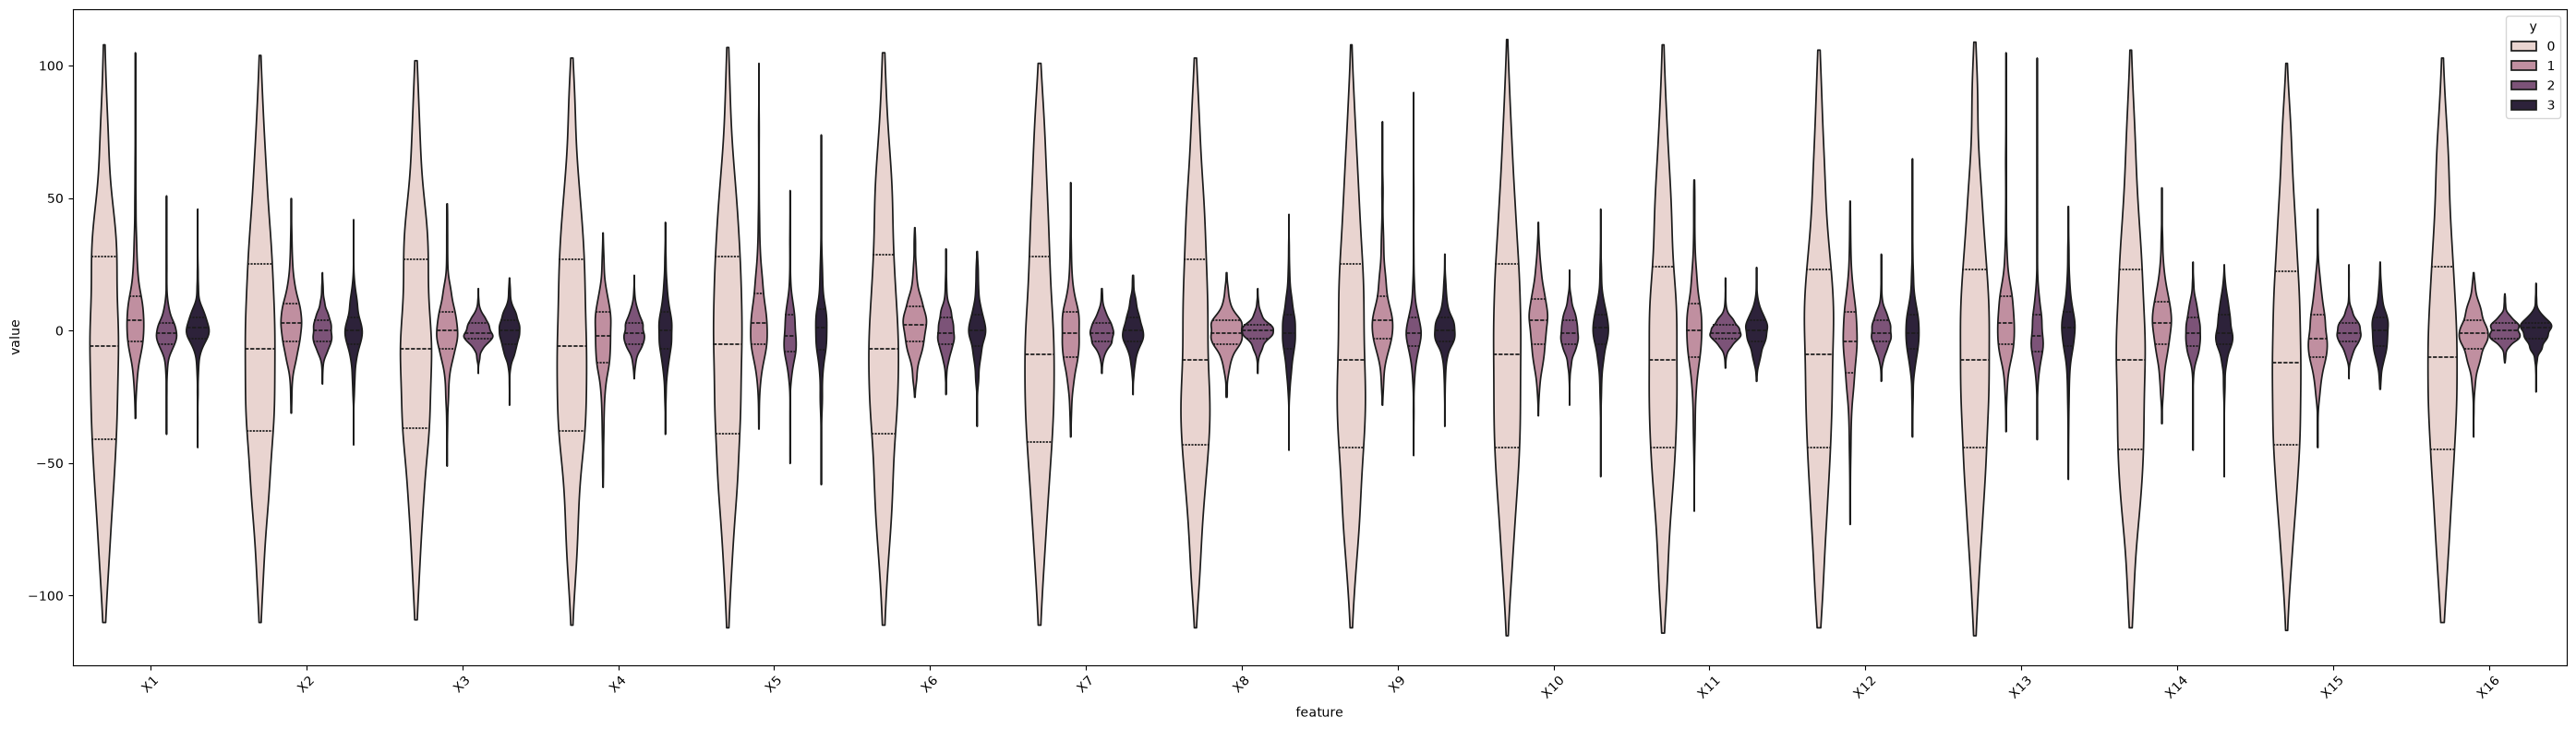

In [22]:
# Violin plots by class for each feature
plot_df = data.melt(id_vars='y', var_name='feature', value_name='value')
plt.figure(figsize=(28, 8))
sns.violinplot(data=plot_df, x='feature', y='value', hue='y', cut=0, inner='quartile')
plt.xticks(rotation=45)
plt.tight_layout()

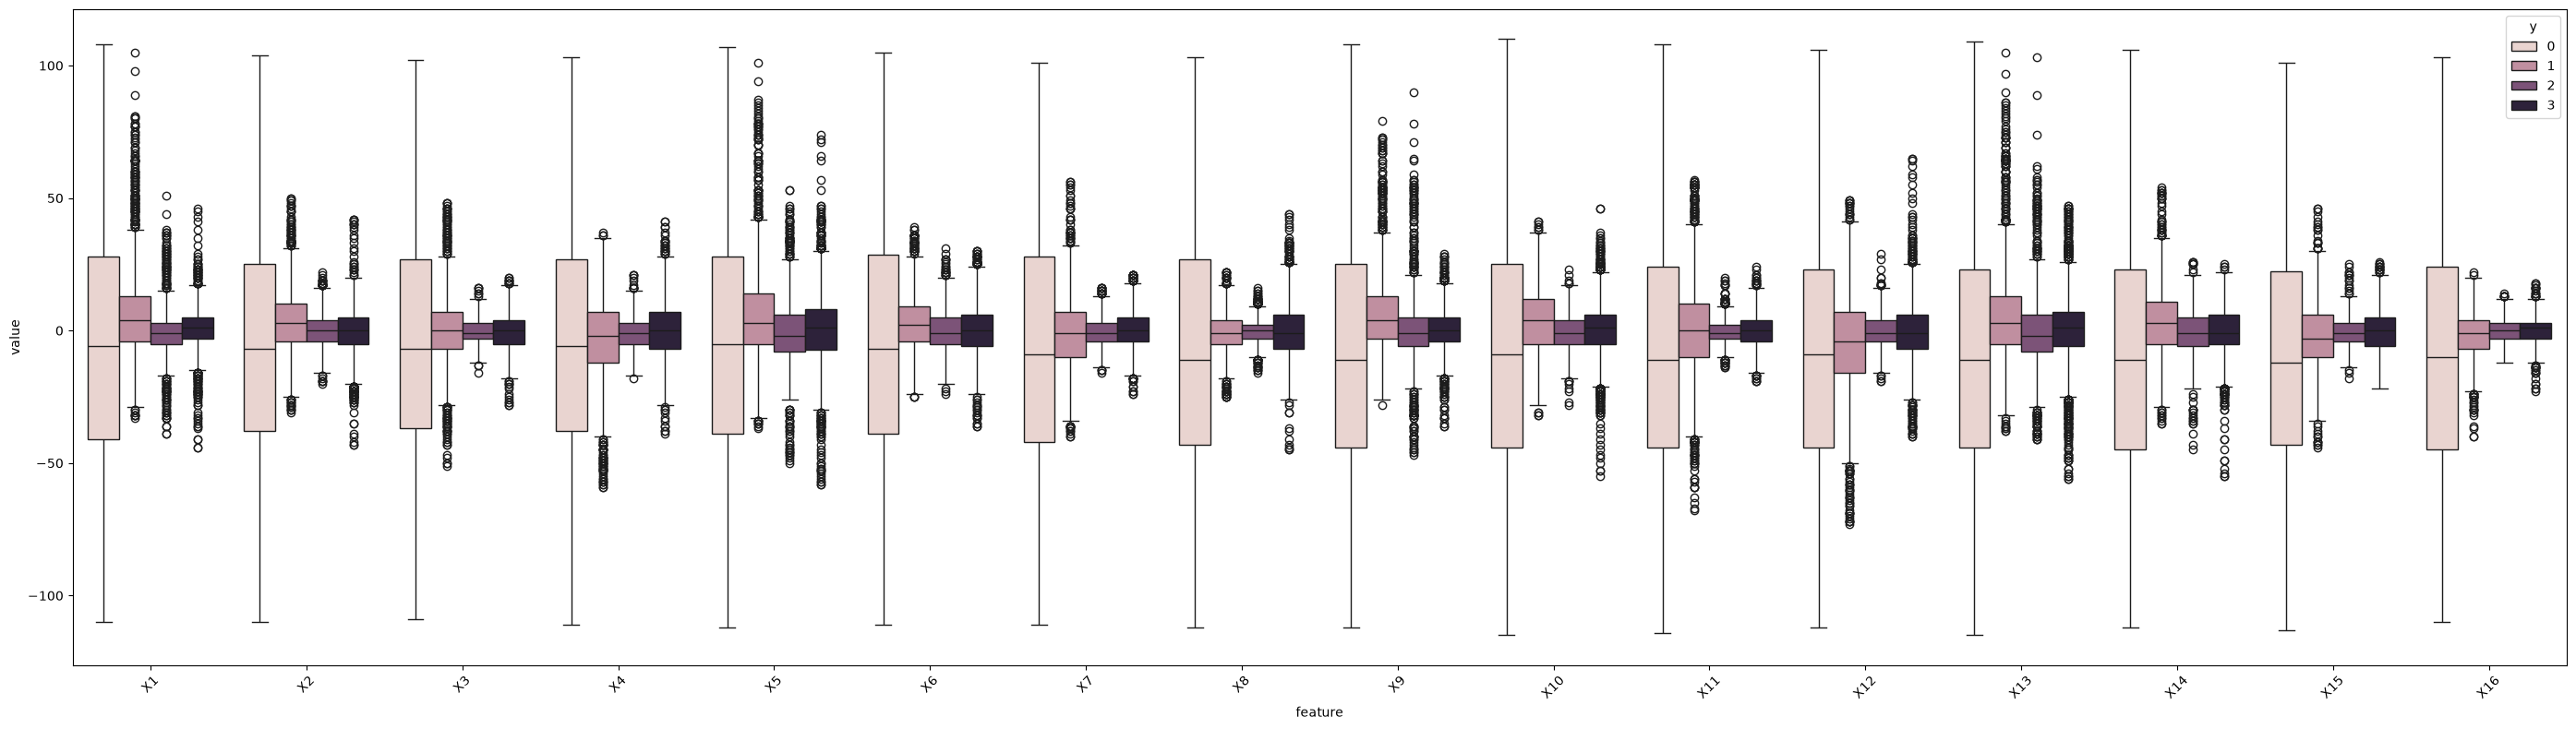

In [23]:
plot_df = data.melt(id_vars='y', var_name='feature', value_name='value')
plt.figure(figsize=(28, 8))
sns.boxplot(data=plot_df, x='feature', y='value', hue='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Certainly harder with boxplots to spot anything. Also dificult with the violin plots.

*Post-hoc comparisons: Tukey's HSD and Dunn's test*

- Tukey’s HSD after ANOVA: Tukey’s honestly significant difference (HSD) test compares all class pairs while controlling the family-wise error rate.

- Dunn’s test after Kruskal–Wallis: Dunn’s test is a common rank-based post-hoc comparison.

**Tukey's HSD:**

In [26]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_results = {}
tukey_rows = []

for feature in feature_columns:
    result = pairwise_tukeyhsd(
        endog=data[feature],
        groups=data["y"],
        alpha=0.05,
    )
    tukey_results[feature] = result

    result_df = pd.DataFrame(
        result.summary().data[1:],
        columns=result.summary().data[0],
    )

    result_df["feature"] = feature
    result_df = result_df[result_df["reject"]].copy()

    tukey_rows.append(
        result_df[
            ["feature", "group1", "group2", "meandiff", "p-adj", "lower", "upper"]
        ]
    )

tukey_significant = (
    pd.concat(tukey_rows, ignore_index=True)
    .sort_values(["feature", "p-adj"])
    .reset_index(drop=True)
)

tukey_feature_summary = (
    tukey_significant.groupby("feature")
    .agg(
        significant_pairs=("feature", "size"),
        smallest_p=("p-adj", "min"),
    )
    .sort_values(["significant_pairs", "smallest_p"], ascending=[False, True])
)

display(tukey_feature_summary)

,significant_pairs,smallest_p
feature,,
X1,5,0.0
X10,5,0.0
X12,5,0.0
X13,5,0.0
X14,5,0.0
X2,5,0.0
X5,5,0.0
X6,5,0.0
X9,5,0.0


Reject H0 when p-adj < 0.05: the two group means are significantly different (significant pair) and therefore contains more information.

Fail to reject H0 when p-adj ≥ 0.05: there is insufficient evidence of a difference—not proof that the means are equal.

**Dunn's Test:**